---
# Part 1: Generate Realistic Windowing Datasets

This section shows how to generate realistic windowing datasets using `realistic_windowing.py`.

## 1. Quick Start: Generate Datasets

Run these commands directly to generate realistic windowing datasets.

In [ ]:
# Standard dataset - Train split (W=2.0s, 2000 samples)
!python realistic_windowing.py --dataset-type standard --input-dir CE_dataset --raw-data-dir Multimodal --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split train --n-samples 2000 --gpu-id 0

In [ ]:
# Standard dataset - Val split (W=2.0s)
!python realistic_windowing.py --dataset-type standard --input-dir CE_dataset --raw-data-dir Multimodal --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split val --gpu-id 0

In [ ]:
# Standard dataset - Test (cross-subject, Subject 5, 5min, 15min, 30min)
!python realistic_windowing.py --dataset-type standard  --input-dir CE_dataset --raw-data-dir Multimodal --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split test --duration 15 --gpu-id 0

In [1]:
# Standard dataset - Test (within-subject/rule-only, Subjects 1-4, 15min, 30min)
!python realistic_windowing.py  --dataset-type standard --input-dir CE_dataset --raw-data-dir Multimodal --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split test  --duration 15 --rule-only --gpu-id 0
!python realistic_windowing.py  --dataset-type standard --input-dir CE_dataset --raw-data-dir Multimodal --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split test  --duration 30 --rule-only --gpu-id 0


REALISTIC WINDOWING - STANDARD DATASET
Dataset type:     Standard (with embeddings)
Device:           cuda:0
Detection window: 2.0s

Loading models...
  Loading BEATs audio model from ./saved_models/BEATs/BEATs_iter3_plus_AS2M.pt...
/home/nesl/anaconda3/envs/iros24/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")
  ✓ BEATs model loaded on cuda:0
  Loading LIMUBert IMU model from ./saved_models/LIMUBert/saved/pretrain_base_wisdm_20_100/wisdm.pt...
  ✓ LIMUBert model loaded on cuda:0
  Loading multimodal fusion model from ./saved_models/multimodal_embed_model_w2.0.pt...
  ✓ Multimodal fusion model loaded on cuda:0

################################################################################
# Processing TEST split (rule-only)
###################

In [ ]:
# NAR dataset - Train split (W=2.0s, 40000 samples)
!python realistic_windowing.py \
    --dataset-type nar \
    --input-dir CE_dataset/nar \
    --detection-window 2.0 \
    --output-dir CE_dataset/nar_w2.0s \
    --split train \
    --n-samples 40000

In [ ]:
# NAR dataset - Val split (W=2.0s)
!python realistic_windowing.py \
    --dataset-type nar \
    --input-dir CE_dataset/nar \
    --detection-window 2.0 \
    --output-dir CE_dataset/nar_w2.0s \
    --split val

In [ ]:
# NAR dataset - Test (5min)
!python realistic_windowing.py \
    --dataset-type nar \
    --input-dir CE_dataset/nar \
    --detection-window 2.0 \
    --output-dir CE_dataset/nar_w2.0s \
    --split test \
    --duration 15

In [4]:
# Generate AE2CE from existing realistic windowing embeddings - Train split
!python realistic_windowing.py --dataset-type standard --input-dir CE_dataset --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split train --n-samples 10000 --ae2ce
!python realistic_windowing.py --dataset-type standard --input-dir CE_dataset --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split val --ae2ce
!python realistic_windowing.py --dataset-type standard --input-dir CE_dataset --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split test --duration 5 --ae2ce
!python realistic_windowing.py --dataset-type standard --input-dir CE_dataset --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split test --duration 15 --ae2ce
!python realistic_windowing.py --dataset-type standard --input-dir CE_dataset --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split test --duration 30 --ae2ce


REALISTIC WINDOWING - AE2CE GENERATION
Mode:             One-hot AE2CE
Device:           cuda:0
Detection window: 2.0s
Split:            train
N samples:        10000

Loading AE classifier...
  Loading AE classifier from ./saved_models/AE_classifier_w2.5.pt...
  ✓ AE classifier loaded on cuda:0

AE2CE DATASET GENERATION FROM REALISTIC WINDOWING
Input embeddings: CE_dataset/realistic_w2.0s/ce5min_train_data_10000.npy
Input labels: CE_dataset/realistic_w2.0s/ce5min_train_labels_10000.npy
Mode: One-hot predictions

[1/2] Loading existing realistic windowing embeddings...
  Embeddings shape: (10000, 150, 128)
  Labels shape: (10000, 150, 10)

[2/2] Generating AE2CE embeddings...
  Generating AE2CE embeddings from fusion...
  Processing 1500000 windows, 128-dim → 9-dim
  Batch size: 512
  Classifying: 100%|█████████████████████| 2930/2930 [00:00<00:00, 17347.22it/s]
  ✓ AE2CE embeddings generated: (1500000, 9)

PROCESSING COMPLETE
Output AE2CE shape: (10000, 150, 9)
Output CE labels shape

In [7]:
# Generate AE2CE from existing realistic windowing embeddings - Train split
!python realistic_windowing.py --dataset-type standard --input-dir CE_dataset --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split train --n-samples 2000 --soft-ae2ce



REALISTIC WINDOWING - AE2CE GENERATION
Mode:             Soft AE2CE
Device:           cuda:0
Detection window: 2.0s
Split:            train
N samples:        2000

Loading AE classifier...
  Loading AE classifier from ./saved_models/AE_classifier_w2.5.pt...
  ✓ AE classifier loaded on cuda:0

AE2CE DATASET GENERATION FROM REALISTIC WINDOWING
Input embeddings: CE_dataset/realistic_w2.0s/ce5min_train_data_2000.npy
Input labels: CE_dataset/realistic_w2.0s/ce5min_train_labels_2000.npy
Mode: Soft probabilities

[1/2] Loading existing realistic windowing embeddings...
  Embeddings shape: (2000, 150, 128)
  Labels shape: (2000, 150, 10)

[2/2] Generating AE2CE embeddings...
  Generating soft-AE2CE embeddings from fusion...
  Processing 300000 windows, 128-dim → 9-dim
  Batch size: 512
  Classifying: 100%|███████████████████████| 586/586 [00:00<00:00, 14748.82it/s]
  ✓ AE2CE embeddings generated: (300000, 9)

PROCESSING COMPLETE
Output AE2CE shape: (2000, 150, 9)
Output CE labels shape: (2000

In [ ]:
!python realistic_windowing.py --dataset-type standard --input-dir CE_dataset --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split val --soft-ae2ce
!python realistic_windowing.py --dataset-type standard --input-dir CE_dataset --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split test --duration 5 --soft-ae2ce
!python realistic_windowing.py --dataset-type standard --input-dir CE_dataset --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split test --duration 15 --soft-ae2ce
!python realistic_windowing.py --dataset-type standard --input-dir CE_dataset --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s --split test --duration 30 --soft-ae2ce

# Realistic Windowing Data Exploration

This notebook provides tools to:
1. **Verify vectorization logic** in `realistic_windowing.py`
2. **Explore CE class distributions** in realistic windowing datasets
3. **Compare different detection window sizes** (W=1.0s, 2.0s, 2.5s, etc.)

## Dataset Types

- **Standard (W=2.5s)**: `CE_dataset/standard/` - Baseline with 2.5s detection windows
- **Realistic (W=X.Xs)**: `CE_dataset/realistic_wX.Xs/` - Variable window sizes with fresh embeddings
  - Contains: `ce5min_{split}_data_{n}.npy`, `ce5min_{split}_ae_{n}.npy`, `ce5min_{split}_labels_{n}.npy`
  - `_data`: Fresh embeddings (n × n_windows_W × 128)
  - `_ae`: Noisy AE labels after majority voting (n × n_windows_W)
  - `_labels`: Multi-label CE labels (n × n_windows_W × 10)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown
import json

# Configure display
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
%matplotlib inline

# CE label mapping
ce_labels_names = {
    1: 'Event 1: Post-toilet handwashing',
    2: 'Event 2: Pre-meal handwashing',
    3: 'Event 3: Insufficient brushing (<120s)',
    4: 'Event 4: Post-meal routine',
    5: 'Event 5: Work session pattern',
    6: 'Event 6: Adequate handwashing (30s)',
    7: 'Event 7: Adequate brushing (≥120s)',
    8: 'Event 8: Post-meal rest (180s)',
    9: 'Event 9: Active typing (3 sessions)',
    10: 'Event 10: Focused work (5 clicks)'
}

# AE label mapping
ae_labels_inv = {
    0: 'brush_teeth',
    1: 'click_mouse',
    2: 'drink',
    3: 'eat',
    4: 'flush_toilet',
    5: 'sit',
    6: 'type',
    7: 'walk',
    8: 'wash'
}

---
# Part 1: Vectorization Verification

Verify correctness of time window mapping, concatenation, and array transformations.

## 1. Time Window Mapping

**Goal**: Verify that each W-second detection window correctly maps to contributing 2.5s raw windows.

**Key Logic** (`realistic_windowing.py:281-303`):
```python
start_pos = int(start_time // original_window_sec)
end_pos = int(np.ceil(end_time / original_window_sec))

overlap_start = max(start_time, window_start)
overlap_end = min(end_time, window_end)

offset_start = overlap_start - window_start
offset_end = overlap_end - window_start
```

In [2]:
def verify_time_window_mapping(detection_window_sec=2.0):
    """Verify detection windows map correctly to original 2.5s windows."""
    
    # Test case: 5-minute CE
    original_window_sec = 2.5
    n_original_windows = 120  # 5 minutes / 2.5s
    total_duration = n_original_windows * original_window_sec  # 300s
    n_detection_windows = int(total_duration / detection_window_sec)

    print(f"Configuration: W={detection_window_sec}s detection windows")
    print(f"Original windows: {n_original_windows} × {original_window_sec}s = {total_duration}s")
    print(f"Detection windows: {n_detection_windows} × {detection_window_sec}s = {total_duration}s")
    print()

    # Test critical windows: start, transitions, end
    test_windows = [0, 1, 2, n_detection_windows//2, n_detection_windows-1]
    results = []

    for window_idx in test_windows:
        # Detection window time range
        start_time = window_idx * detection_window_sec
        end_time = start_time + detection_window_sec

        # Which 2.5s windows contribute?
        start_pos = int(start_time // original_window_sec)
        end_pos = int(np.ceil(end_time / original_window_sec))
        start_pos = max(0, start_pos)
        end_pos = min(n_original_windows, end_pos)

        print(f"Detection Window {window_idx}: [{start_time:.1f}s - {end_time:.1f}s)")

        total_coverage = 0
        
        for position_idx in range(start_pos, end_pos):
            window_start = position_idx * original_window_sec
            window_end = window_start + original_window_sec

            overlap_start = max(start_time, window_start)
            overlap_end = min(end_time, window_end)

            offset_start = overlap_start - window_start
            offset_end = overlap_end - window_start
            coverage = offset_end - offset_start
            total_coverage += coverage

            print(f"  Uses 2.5s window {position_idx}: offset [{offset_start:.1f}s - {offset_end:.1f}s) = {coverage:.1f}s")

        expected_coverage = detection_window_sec
        status = "✓" if abs(total_coverage - expected_coverage) < 0.01 else "✗"
        print(f"  Total: {total_coverage:.1f}s (expected: {expected_coverage:.1f}s) {status}\n")
        
        results.append({
            'Detection Window': window_idx,
            'Time Range': f"[{start_time:.1f}s - {end_time:.1f}s)",
            'Contributing Windows': end_pos - start_pos,
            'Total Coverage': f"{total_coverage:.1f}s",
            'Status': status
        })

    df = pd.DataFrame(results)
    display(df)
    
    return df

# Test with W=2.0s
verify_time_window_mapping(detection_window_sec=2.0)

Configuration: W=2.0s detection windows
Original windows: 120 × 2.5s = 300.0s
Detection windows: 150 × 2.0s = 300.0s

Detection Window 0: [0.0s - 2.0s)
  Uses 2.5s window 0: offset [0.0s - 2.0s) = 2.0s
  Total: 2.0s (expected: 2.0s) ✓

Detection Window 1: [2.0s - 4.0s)
  Uses 2.5s window 0: offset [2.0s - 2.5s) = 0.5s
  Uses 2.5s window 1: offset [0.0s - 1.5s) = 1.5s
  Total: 2.0s (expected: 2.0s) ✓

Detection Window 2: [4.0s - 6.0s)
  Uses 2.5s window 1: offset [1.5s - 2.5s) = 1.0s
  Uses 2.5s window 2: offset [0.0s - 1.0s) = 1.0s
  Total: 2.0s (expected: 2.0s) ✓

Detection Window 75: [150.0s - 152.0s)
  Uses 2.5s window 60: offset [0.0s - 2.0s) = 2.0s
  Total: 2.0s (expected: 2.0s) ✓

Detection Window 149: [298.0s - 300.0s)
  Uses 2.5s window 119: offset [0.5s - 2.5s) = 2.0s
  Total: 2.0s (expected: 2.0s) ✓



,Detection Window,Time Range,Contributing Windows,Total Coverage,Status
0,0,[0.0s - 2.0s),1,2.0s,✓
1,1,[2.0s - 4.0s),2,2.0s,✓
2,2,[4.0s - 6.0s),2,2.0s,✓
3,75,[150.0s - 152.0s),1,2.0s,✓
4,149,[298.0s - 300.0s),1,2.0s,✓


,Detection Window,Time Range,Contributing Windows,Total Coverage,Status
0,0,[0.0s - 2.0s),1,2.0s,✓
1,1,[2.0s - 4.0s),2,2.0s,✓
2,2,[4.0s - 6.0s),2,2.0s,✓
3,75,[150.0s - 152.0s),1,2.0s,✓
4,149,[298.0s - 300.0s),1,2.0s,✓


## 2. Audio/IMU Concatenation Verification

Verify that audio (16kHz) and IMU (20Hz) chunks are concatenated correctly.

In [3]:
def verify_concatenation(detection_window_sec=2.0):
    """Verify audio and IMU concatenation math."""
    
    audio_sample_rate = 16000
    imu_sample_rate = 20
    original_window_sec = 2.5

    expected_audio = int(detection_window_sec * audio_sample_rate)
    expected_imu = int(detection_window_sec * imu_sample_rate)
    
    print(f"Expected samples per {detection_window_sec}s detection window:")
    print(f"  Audio: {expected_audio} samples @ 16kHz")
    print(f"  IMU:   {expected_imu} samples @ 20Hz\n")

    # Test case: Detection window [2.0s - 4.0s) spans two 2.5s windows
    print(f"Test: Detection window [2.0s - 4.0s)")
    print("="*60)
    
    chunks = [
        {'window': 0, 'offset_start': 2.0, 'offset_end': 2.5},
        {'window': 1, 'offset_start': 0.0, 'offset_end': 1.5}
    ]

    audio_total = 0
    imu_total = 0
    
    for i, chunk in enumerate(chunks):
        offset_start = chunk['offset_start']
        offset_end = chunk['offset_end']
        
        audio_start = int(offset_start * audio_sample_rate)
        audio_end = int(offset_end * audio_sample_rate)
        audio_samples = audio_end - audio_start
        
        imu_start = int(offset_start * imu_sample_rate)
        imu_end = int(offset_end * imu_sample_rate)
        imu_samples = imu_end - imu_start
        
        audio_total += audio_samples
        imu_total += imu_samples
        
        print(f"Chunk {i} (2.5s window {chunk['window']}):")
        print(f"  Audio: [{audio_start}:{audio_end}] = {audio_samples} samples")
        print(f"  IMU:   [{imu_start}:{imu_end}] = {imu_samples} samples")
    
    audio_status = "✓" if audio_total == expected_audio else "✗"
    imu_status = "✓" if imu_total == expected_imu else "✗"
    
    print(f"\nConcatenated totals:")
    print(f"  Audio: {audio_total} samples (expected: {expected_audio}) {audio_status}")
    print(f"  IMU:   {imu_total} samples (expected: {expected_imu}) {imu_status}")

verify_concatenation(detection_window_sec=2.0)

Expected samples per 2.0s detection window:
  Audio: 32000 samples @ 16kHz
  IMU:   40 samples @ 20Hz

Test: Detection window [2.0s - 4.0s)
Chunk 0 (2.5s window 0):
  Audio: [32000:40000] = 8000 samples
  IMU:   [40:50] = 10 samples
Chunk 1 (2.5s window 1):
  Audio: [0:24000] = 24000 samples
  IMU:   [0:30] = 30 samples

Concatenated totals:
  Audio: 32000 samples (expected: 32000) ✓
  IMU:   40 samples (expected: 40) ✓


## 3. Memory Optimization Comparison

Compare old (all-at-once) vs new (batched) memory usage.

Memory Usage Comparison for W=2.0s (150 windows)



,Dataset Size,Old Memory (GB),New Memory (GB),Num Batches,Reduction
0,2000,38.69,9.67,4,4.0x
1,4000,77.38,9.67,8,8.0x
2,6000,116.06,9.67,12,12.0x
3,8000,154.75,9.67,16,16.0x
4,10000,193.44,9.67,20,20.0x


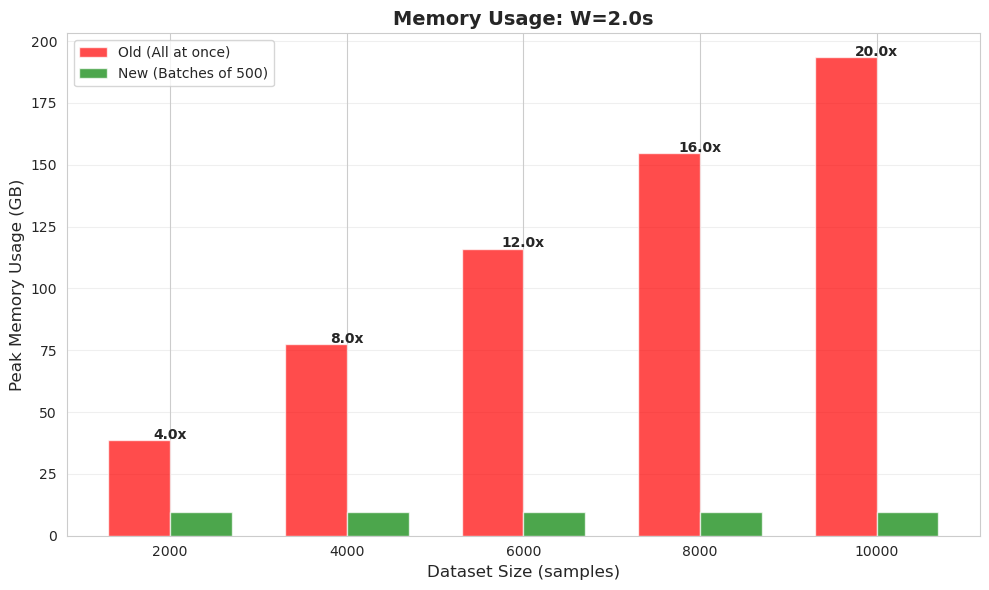

,Dataset Size,Old Memory (GB),New Memory (GB),Num Batches,Reduction
0,2000,38.69,9.67,4,4.0x
1,4000,77.38,9.67,8,8.0x
2,6000,116.06,9.67,12,12.0x
3,8000,154.75,9.67,16,16.0x
4,10000,193.44,9.67,20,20.0x


In [4]:
def compare_memory_usage(detection_window_sec=2.0):
    """Compare memory usage: old vs new approach."""
    
    n_detection_windows = int(300 / detection_window_sec)  # 5 minutes
    audio_sample_size = int(detection_window_sec * 16000)
    imu_sample_size = int(detection_window_sec * 20)
    
    dataset_sizes = [2000, 4000, 6000, 8000, 10000]
    sample_batch_size = 500
    
    results = []
    
    for n_samples in dataset_sizes:
        # Old approach: all at once
        old_audio_gb = n_samples * n_detection_windows * 1 * audio_sample_size * 4 / 1e9
        old_imu_gb = n_samples * n_detection_windows * 6 * imu_sample_size * 4 / 1e9
        old_total_gb = old_audio_gb + old_imu_gb
        
        # New approach: batches of 500
        new_audio_gb = sample_batch_size * n_detection_windows * 1 * audio_sample_size * 4 / 1e9
        new_imu_gb = sample_batch_size * n_detection_windows * 6 * imu_sample_size * 4 / 1e9
        new_total_gb = new_audio_gb + new_imu_gb
        
        num_batches = (n_samples + sample_batch_size - 1) // sample_batch_size
        reduction = old_total_gb / new_total_gb
        
        results.append({
            'Dataset Size': n_samples,
            'Old Memory (GB)': f"{old_total_gb:.2f}",
            'New Memory (GB)': f"{new_total_gb:.2f}",
            'Num Batches': num_batches,
            'Reduction': f"{reduction:.1f}x"
        })
    
    df = pd.DataFrame(results)
    
    print(f"Memory Usage Comparison for W={detection_window_sec}s ({n_detection_windows} windows)")
    print(f"{'='*80}\n")
    display(df)
    
    # Visualization
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    x = np.arange(len(dataset_sizes))
    old_mem = [float(r['Old Memory (GB)']) for r in results]
    new_mem = [float(r['New Memory (GB)']) for r in results]
    
    width = 0.35
    ax.bar(x - width/2, old_mem, width, label='Old (All at once)', color='red', alpha=0.7)
    ax.bar(x + width/2, new_mem, width, label='New (Batches of 500)', color='green', alpha=0.7)
    
    ax.set_xlabel('Dataset Size (samples)', fontsize=12)
    ax.set_ylabel('Peak Memory Usage (GB)', fontsize=12)
    ax.set_title(f'Memory Usage: W={detection_window_sec}s', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(dataset_sizes)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    for i, (o, n) in enumerate(zip(old_mem, new_mem)):
        reduction = o / n
        ax.text(i, max(o, n) + 0.5, f"{reduction:.1f}x", ha='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return df

compare_memory_usage(detection_window_sec=2.0)

---
# Part 2: CE Class Distribution Analysis

Load and explore CE class distributions in realistic windowing datasets.

## 4. Load Realistic Windowing Dataset

In [5]:
def load_realistic_dataset(window_size=2.0, split='train', n_samples=2000):
    """Load realistic windowing dataset.
    
    Args:
        window_size: Detection window size (1.0, 2.0, 2.5, 5.0, etc.)
        split: 'train', 'val', or 'test'
        n_samples: Number of samples (for train split)
    
    Returns:
        tuple: (embeddings, ae_labels, ce_labels, info)
    """
    data_dir = Path(f'CE_dataset/realistic_w{window_size}s')
    
    if split == 'train':
        data_file = data_dir / f'ce5min_train_data_{n_samples}.npy'
        ae_file = data_dir / f'ce5min_train_ae_{n_samples}.npy'
        labels_file = data_dir / f'ce5min_train_labels_{n_samples}.npy'
    elif split == 'val':
        data_file = data_dir / f'ce5min_val_data.npy'
        ae_file = data_dir / f'ce5min_val_ae.npy'
        labels_file = data_dir / f'ce5min_val_labels.npy'
    elif split == 'test':
        data_file = data_dir / f'ce5min_test_data.npy'
        ae_file = data_dir / f'ce5min_test_ae.npy'
        labels_file = data_dir / f'ce5min_test_labels.npy'
    else:
        raise ValueError(f"Invalid split: {split}")
    
    if not data_file.exists():
        raise FileNotFoundError(f"Dataset not found: {data_file}\nGenerate it first using realistic_windowing.py")
    
    embeddings = np.load(data_file)
    ae_labels = np.load(ae_file)
    ce_labels = np.load(labels_file)
    
    info = {
        'window_size': window_size,
        'split': split,
        'n_samples': embeddings.shape[0],
        'n_windows': embeddings.shape[1],
        'embed_dim': embeddings.shape[2],
        'data_file': str(data_file)
    }
    
    return embeddings, ae_labels, ce_labels, info

# Example: Load W=2.0s dataset
try:
    embeddings, ae_labels, ce_labels, info = load_realistic_dataset(
        window_size=2.0, 
        split='train', 
        n_samples=2000
    )
    
    print("Dataset Loaded Successfully")
    print("="*70)
    for key, value in info.items():
        print(f"  {key:15s}: {value}")
    
    print(f"\nShapes:")
    print(f"  Embeddings: {embeddings.shape}  (samples, windows, features)")
    print(f"  AE Labels:  {ae_labels.shape}  (samples, windows)")
    print(f"  CE Labels:  {ce_labels.shape}  (samples, windows, events)")
    
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("\nTo generate realistic windowing datasets, run:")
    print("  python realistic_windowing.py --input-dir CE_dataset --raw-data-dir Multimodal \\")
    print("    --detection-window 2.0 --output-dir CE_dataset/realistic_w2.0s \\")
    print("    --split train --n-samples 2000 --gpu-id 0")

Dataset Loaded Successfully
  window_size    : 2.0
  split          : train
  n_samples      : 2000
  n_windows      : 150
  embed_dim      : 128
  data_file      : CE_dataset/realistic_w2.0s/ce5min_train_data_2000.npy

Shapes:
  Embeddings: (2000, 150, 128)  (samples, windows, features)
  AE Labels:  (2000, 150)  (samples, windows)
  CE Labels:  (2000, 150, 10)  (samples, windows, events)


## 5. Multi-Label CE Analysis

In [ ]:
def analyze_multilabel_ce(ce_labels):
    """Analyze multi-label CE distribution."""
    
    print("="*70)
    print("Multi-Label CE Analysis")
    print("="*70)
    
    # Count events per window
    events_per_window = np.sum(ce_labels, axis=2)  # (n_samples, n_windows)
    
    print(f"\nEvents per window statistics:")
    print(f"  Mean:   {events_per_window.mean():.3f}")
    print(f"  Median: {np.median(events_per_window):.1f}")
    print(f"  Max:    {int(events_per_window.max())}")
    
    # Multi-event windows
    multi_event_windows = np.sum(events_per_window > 1)
    total_windows = events_per_window.size
    print(f"\nWindows with multiple events: {multi_event_windows}/{total_windows} ({multi_event_windows/total_windows*100:.2f}%)")
    
    # Window-level distribution
    print(f"\nWindow-level distribution:")
    unique_counts, count_freqs = np.unique(events_per_window, return_counts=True)
    for n_events, freq in zip(unique_counts, count_freqs):
        print(f"  {int(n_events)} events: {freq:6d} windows ({freq/total_windows*100:5.2f}%)")
    
    # Per-event distribution
    print(f"\n{'='*70}")
    print("Per-Event Distribution")
    print(f"{'='*70}\n")
    
    n_events = ce_labels.shape[2]
    event_stats = []
    
    for event_idx in range(n_events):
        event_id = event_idx + 1
        event_occurrences = np.sum(ce_labels[:, :, event_idx])
        samples_with_event = np.sum(np.any(ce_labels[:, :, event_idx], axis=1))
        
        event_stats.append({
            'Event': event_id,
            'Name': ce_labels_names.get(event_id, f'Event {event_id}'),
            'Windows': int(event_occurrences),
            'Window %': f"{event_occurrences/total_windows*100:.2f}%",
            'Samples': int(samples_with_event),
            'Sample %': f"{samples_with_event/ce_labels.shape[0]*100:.2f}%"
        })
    
    df = pd.DataFrame(event_stats)
    display(df)
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Window distribution
    ax1.bar(df['Event'], df['Windows'])
    ax1.set_xlabel('Event ID')
    ax1.set_ylabel('Number of Windows')
    ax1.set_title('CE Events: Window-Level Distribution')
    ax1.grid(axis='y', alpha=0.3)
    
    # Sample distribution
    ax2.bar(df['Event'], df['Samples'], color='orange')
    ax2.set_xlabel('Event ID')
    ax2.set_ylabel('Number of Samples')
    ax2.set_title('CE Events: Sample-Level Distribution')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return df

# Run analysis
try:
    event_stats = analyze_multilabel_ce(ce_labels)
except NameError:
    print("Load dataset first (Section 4)")

## 6. CE Per-Sample Distribution

In [ ]:
def analyze_ce_per_sample(ce_labels):
    """Analyze CE distribution at the sample level.
    
    This function analyzes which events appear in each sample (regardless of how many windows),
    providing a sample-level view of event presence.
    """
    
    print("="*70)
    print("CE Per-Sample Distribution Analysis")
    print("="*70)
    
    n_samples = ce_labels.shape[0]
    n_events = ce_labels.shape[2]
    
    # Create sample-level event presence matrix (n_samples, n_events)
    # sample_events[i, j] = 1 if Event j+1 appears in sample i (at any window)
    sample_events = np.any(ce_labels, axis=1).astype(int)
    
    # Statistics: events per sample
    events_per_sample = np.sum(sample_events, axis=1)  # (n_samples,)
    
    print(f"\nEvents per sample statistics:")
    print(f"  Mean:   {events_per_sample.mean():.3f}")
    print(f"  Median: {np.median(events_per_sample):.1f}")
    print(f"  Min:    {int(events_per_sample.min())}")
    print(f"  Max:    {int(events_per_sample.max())}")
    
    # Distribution of number of events per sample
    print(f"\nSample-level event distribution:")
    unique_counts, count_freqs = np.unique(events_per_sample, return_counts=True)
    for n_events_val, freq in zip(unique_counts, count_freqs):
        print(f"  {int(n_events_val)} events: {freq:5d} samples ({freq/n_samples*100:5.2f}%)")
    
    # Per-event sample presence
    print(f"\n{'='*70}")
    print("Event Presence Across Samples")
    print(f"{'='*70}\n")
    
    event_presence = []
    for event_idx in range(10):
        event_id = event_idx + 1
        samples_with_event = np.sum(sample_events[:, event_idx])
        
        event_presence.append({
            'Event': event_id,
            'Name': ce_labels_names.get(event_id, f'Event {event_id}'),
            'Samples': int(samples_with_event),
            'Percentage': f"{samples_with_event/n_samples*100:.2f}%"
        })
    
    df = pd.DataFrame(event_presence)
    display(df)
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Events per sample histogram
    ax1.hist(events_per_sample, bins=range(int(events_per_sample.min()), 
                                           int(events_per_sample.max())+2), 
             edgecolor='black', alpha=0.7, color='steelblue')
    ax1.set_xlabel('Number of Events per Sample')
    ax1.set_ylabel('Number of Samples')
    ax1.set_title('Distribution of Events per Sample')
    ax1.grid(axis='y', alpha=0.3)
    
    # Event presence across samples
    ax2.bar(df['Event'], df['Samples'], color='coral')
    ax2.set_xlabel('Event ID')
    ax2.set_ylabel('Number of Samples with Event')
    ax2.set_title('Event Presence Across Samples')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Sample-level co-occurrence
    print(f"\n{'='*70}")
    print("Sample-Level Event Co-occurrence")
    print(f"{'='*70}")
    
    sample_cooccurrence = np.zeros((10, 10), dtype=int)
    
    for sample_idx in range(n_samples):
        active_events = np.where(sample_events[sample_idx] == 1)[0]
        for i in active_events:
            for j in active_events:
                if i != j:
                    sample_cooccurrence[i, j] += 1
    
    # Extract top pairs
    pair_counts = []
    for i in range(10):
        for j in range(i+1, 10):
            count = sample_cooccurrence[i, j] + sample_cooccurrence[j, i]
            if count > 0:
                pair_counts.append((count, i+1, j+1))
    
    pair_counts.sort(reverse=True)
    
    if len(pair_counts) > 0:
        print(f"\nTop event pairs (co-occurring in same sample):\n")
        for count, ev1, ev2 in pair_counts[:10]:
            print(f"Event {ev1} + Event {ev2}: {count} samples ({count/n_samples*100:.2f}%)")
            print(f"  - {ce_labels_names[ev1]}")
            print(f"  - {ce_labels_names[ev2]}\n")
        
        # Heatmap
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(sample_cooccurrence, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=range(1, 11), yticklabels=range(1, 11), ax=ax)
        ax.set_xlabel('Event ID')
        ax.set_ylabel('Event ID')
        ax.set_title('Sample-Level Event Co-occurrence Matrix')
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo event co-occurrences found at sample level.")
    
    return df, sample_events

# Run analysis
try:
    event_presence_df, sample_events_matrix = analyze_ce_per_sample(ce_labels)
except NameError:
    print("Load dataset first (Section 4)")

## 6. Event Co-occurrence Analysis

Event Co-occurrence Analysis

Top event pairs (co-occurring in same window):

Event 1 + Event 8: 14 windows (0.00%)
  - Event 1: Post-toilet handwashing
  - Event 8: Post-meal rest (180s)

Event 2 + Event 4: 6 windows (0.00%)
  - Event 2: Pre-meal handwashing
  - Event 4: Post-meal routine



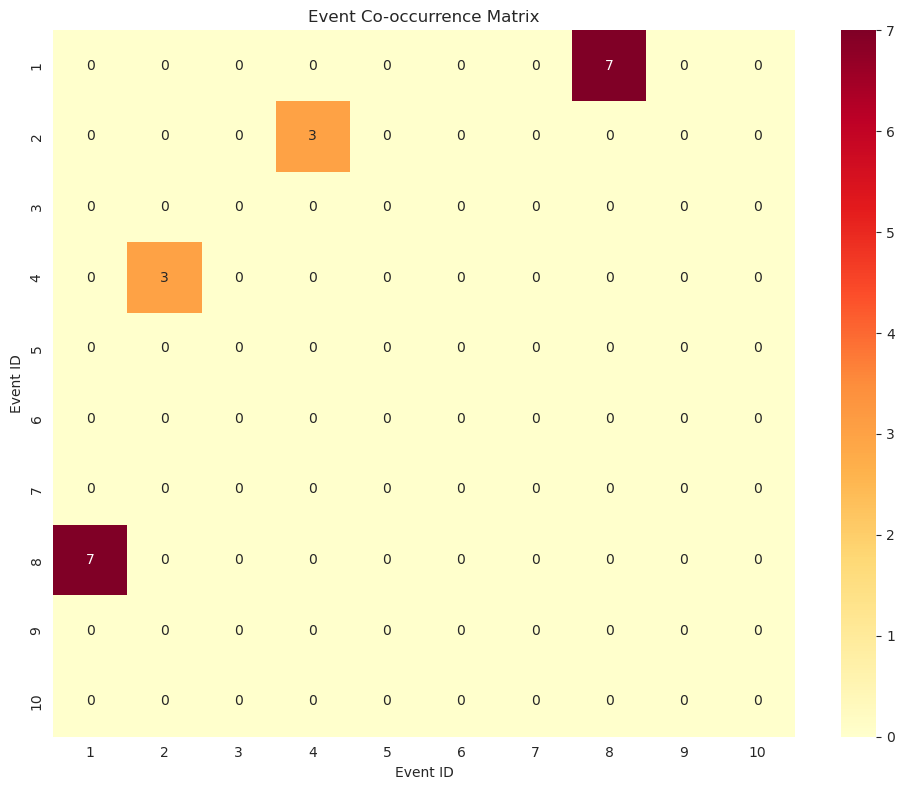

In [7]:
def analyze_event_cooccurrence(ce_labels):
    """Analyze which events co-occur in the same window."""
    
    print("="*70)
    print("Event Co-occurrence Analysis")
    print("="*70)
    
    n_events = 10
    cooccurrence_matrix = np.zeros((n_events, n_events), dtype=int)
    
    # Flatten to (total_windows, n_events)
    labels_flat = ce_labels.reshape(-1, n_events)
    total_windows = labels_flat.shape[0]
    
    for window_labels in labels_flat:
        active_events = np.where(window_labels == 1)[0]
        for i in active_events:
            for j in active_events:
                if i != j:
                    cooccurrence_matrix[i, j] += 1
    
    # Extract pairs
    pair_counts = []
    for i in range(n_events):
        for j in range(i+1, n_events):
            count = cooccurrence_matrix[i, j] + cooccurrence_matrix[j, i]
            if count > 0:
                pair_counts.append((count, i+1, j+1))
    
    pair_counts.sort(reverse=True)
    
    if len(pair_counts) > 0:
        print(f"\nTop event pairs (co-occurring in same window):\n")
        for count, ev1, ev2 in pair_counts[:10]:
            print(f"Event {ev1} + Event {ev2}: {count} windows ({count/total_windows*100:.2f}%)")
            print(f"  - {ce_labels_names[ev1]}")
            print(f"  - {ce_labels_names[ev2]}\n")
    else:
        print("\nNo event co-occurrences found.")
    
    # Heatmap
    if np.sum(cooccurrence_matrix) > 0:
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(cooccurrence_matrix, annot=True, fmt='d', cmap='YlOrRd', 
                    xticklabels=range(1, 11), yticklabels=range(1, 11), ax=ax)
        ax.set_xlabel('Event ID')
        ax.set_ylabel('Event ID')
        ax.set_title('Event Co-occurrence Matrix')
        plt.tight_layout()
        plt.show()

try:
    analyze_event_cooccurrence(ce_labels)
except NameError:
    print("Load dataset first (Section 4)")

## 7. Compare Detection Window Sizes

In [8]:
def compare_window_sizes(window_sizes=[1.0, 2.0, 2.5, 5.0], split='train', n_samples=2000):
    """Compare CE distributions across different window sizes."""
    
    print("="*70)
    print("Comparing Detection Window Sizes")
    print("="*70)
    
    results = []
    
    for w in window_sizes:
        try:
            _, _, ce_labels, info = load_realistic_dataset(w, split, n_samples)
            
            # Count events per window
            events_per_window = np.sum(ce_labels, axis=2)
            total_windows = events_per_window.size
            multi_event = np.sum(events_per_window > 1)
            
            # Per-event counts
            event_counts = []
            for event_idx in range(10):
                count = np.sum(ce_labels[:, :, event_idx])
                event_counts.append(count)
            
            results.append({
                'Window Size': f"{w}s",
                'Num Windows': info['n_windows'],
                'Total Windows': total_windows,
                'Multi-label Windows': multi_event,
                'Multi-label %': f"{multi_event/total_windows*100:.2f}%",
                **{f'Event {i+1}': event_counts[i] for i in range(10)}
            })
            
        except FileNotFoundError:
            print(f"Warning: W={w}s dataset not found, skipping")
    
    if results:
        df = pd.DataFrame(results)
        display(df)
        
        # Visualize event counts across window sizes
        fig, ax = plt.subplots(figsize=(12, 6))
        
        x = np.arange(len(results))
        width = 0.08
        
        for event_idx in range(10):
            counts = [r[f'Event {event_idx+1}'] for r in results]
            ax.bar(x + (event_idx - 4.5) * width, counts, width, 
                   label=f'Event {event_idx+1}')
        
        ax.set_xlabel('Detection Window Size')
        ax.set_ylabel('Event Occurrences')
        ax.set_title('CE Event Distribution vs Detection Window Size')
        ax.set_xticks(x)
        ax.set_xticklabels([r['Window Size'] for r in results])
        ax.legend(ncol=2)
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return df
    else:
        print("No datasets found for comparison.")

# Compare available window sizes
# compare_window_sizes(window_sizes=[2.0, 2.5], split='train', n_samples=2000)

## 8. Visualize Sample with CE Events

Visualizing sample 935 (most CE events)


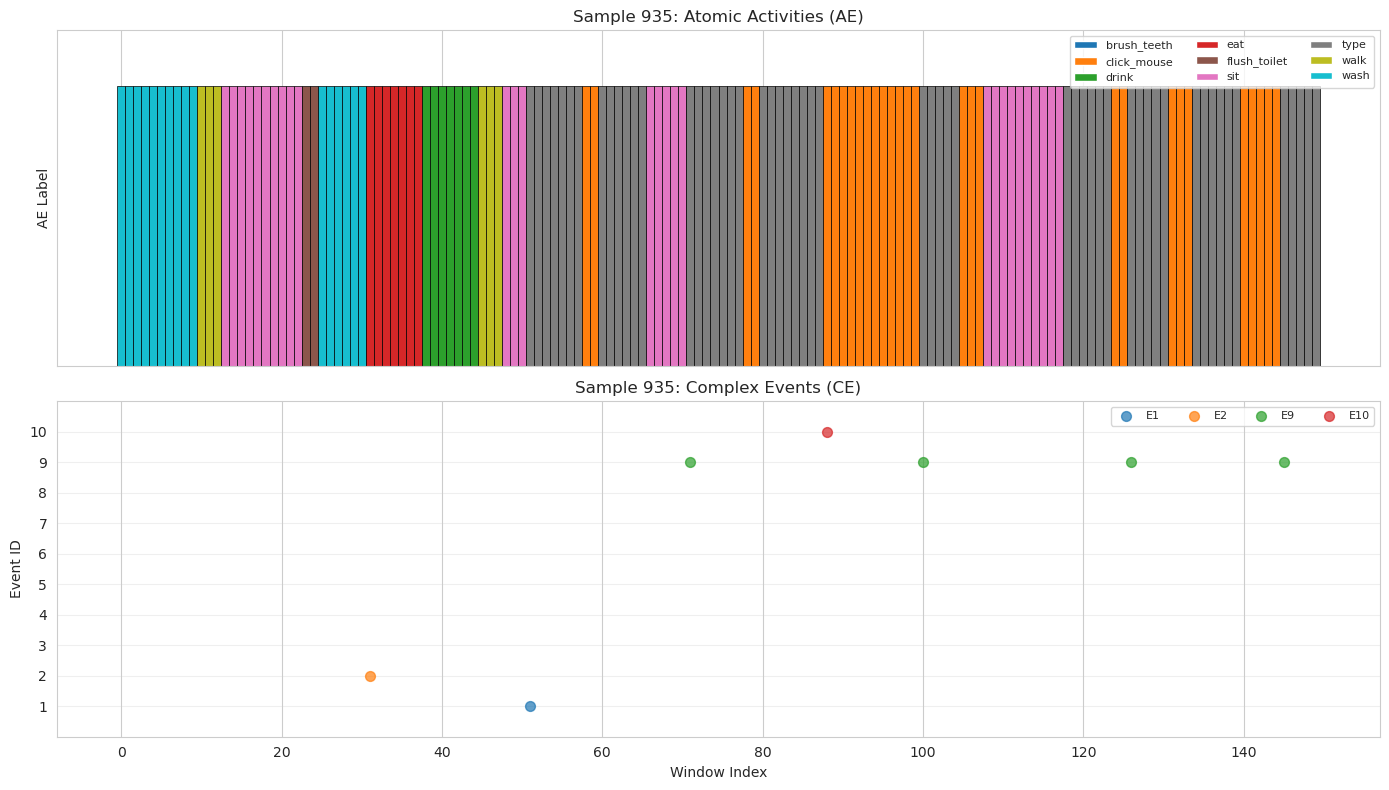

In [9]:
def visualize_sample(sample_idx, ae_labels, ce_labels):
    """Visualize AE and CE labels for a single sample."""
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    n_windows = ae_labels.shape[1]
    x = np.arange(n_windows)
    
    # Plot AE labels
    ae_sample = ae_labels[sample_idx]
    colors = plt.cm.tab10(ae_sample / 8.0)
    ax1.bar(x, np.ones(n_windows), color=colors, width=1.0, edgecolor='black', linewidth=0.5)
    ax1.set_ylabel('AE Label')
    ax1.set_title(f'Sample {sample_idx}: Atomic Activities (AE)')
    ax1.set_ylim([0, 1.2])
    ax1.set_yticks([])
    
    # Legend for AE
    from matplotlib.patches import Patch
    ae_legend = [Patch(facecolor=plt.cm.tab10(i/8.0), label=ae_labels_inv[i]) for i in range(9)]
    ax1.legend(handles=ae_legend, loc='upper right', ncol=3, fontsize=8)
    
    # Plot CE labels
    ce_sample = ce_labels[sample_idx]  # (n_windows, 10)
    
    for event_idx in range(10):
        event_id = event_idx + 1
        windows_with_event = np.where(ce_sample[:, event_idx] == 1)[0]
        
        if len(windows_with_event) > 0:
            ax2.scatter(windows_with_event, [event_id] * len(windows_with_event), 
                       s=50, alpha=0.7, label=f'E{event_id}')
    
    ax2.set_xlabel('Window Index')
    ax2.set_ylabel('Event ID')
    ax2.set_title(f'Sample {sample_idx}: Complex Events (CE)')
    ax2.set_yticks(range(1, 11))
    ax2.set_ylim([0, 11])
    ax2.grid(axis='y', alpha=0.3)
    ax2.legend(loc='upper right', ncol=5, fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Visualize a sample with events
try:
    # Find sample with most events
    total_events = np.sum(ce_labels, axis=(1, 2))
    sample_idx = np.argmax(total_events)
    
    print(f"Visualizing sample {sample_idx} (most CE events)")
    visualize_sample(sample_idx, ae_labels, ce_labels)
except NameError:
    print("Load dataset first (Section 4)")

---
## Summary

This notebook provides:

**Part 1: Vectorization Verification**
- Time window mapping correctness
- Audio/IMU concatenation verification
- Memory optimization analysis

**Part 2: CE Class Distribution**
- Multi-label CE statistics
- Per-event distributions
- Event co-occurrence patterns
- Comparison across window sizes
- Sample visualization

**Next Steps:**
1. Generate realistic windowing datasets using `realistic_windowing.py`
2. Run verification tests (Part 1)
3. Explore CE distributions (Part 2)
4. Compare different detection window sizes